# Taller práctico — Semana 1: Fundamentos matemáticos para Deep Learning

**Maestría**: Inteligencia Artificial Aplicada  
**Asignatura**: Aprendizaje Profundo  
**Profesor**: Jefferson Rodriguez

## Grupo 2

- Karla Mora
- Daniel Barreiros
- Cristian Pachacama

## Objetivo
Resolver problemas prácticos con Python y NumPy para relacionar vectores, matrices, tensores, espacios vectoriales, transformaciones lineales y autovalores/autovectores con las representaciones utilizadas en Deep Learning.

> **Importante:** no basta con obtener un resultado. Explica qué significa matemática y computacionalmente.

## Preparación

In [31]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
print("NumPy:", np.__version__)

NumPy: 2.4.6


## Ejercicio 1 — Representación de observaciones

Se registran cuatro observaciones con tres características:
$$
\begin{bmatrix}
120 & 22 & 65 \\\\
135 & 24 & 60 \\\\
98 & 19 & 72 \\\\
150 & 27 & 55
\end{bmatrix}
$$
### Tareas
1. Construye `X` con NumPy.
2. Obtén `shape`, `ndim` y `dtype`.
3. Extrae la segunda observación, la columna de temperatura y las dos primeras características.
4. Calcula la media de cada característica.
5. Explica por qué es una matriz y cuándo necesitarías un tensor de mayor dimensión.

**Indicio:** usa `shape`, `ndim`, indexación y `mean(axis=0)`.

### 1. Construir X con numpy (4 observaciones, 3 características)

In [32]:
X = np.array([
    [120, 22, 65],
    [135, 24, 60],
    [98, 19, 72],
    [150, 27, 55]
])

print(X)

[[120  22  65]
 [135  24  60]
 [ 98  19  72]
 [150  27  55]]


### 2. Obtén shape, ndim y dtype

In [33]:

print("shape:", X.shape)
print("ndim:", X.ndim)
print("dtype:", X.dtype)

shape: (4, 3)
ndim: 2
dtype: int64


Explicación:

- shape: (4, 3) → La matriz tiene 4 filas y 3 columnas. En nuestro caso, representa 4 observaciones y 3 características.
- ndim: 2 → El arreglo tiene 2 dimensiones, porque está organizado en filas y columnas.
- dtype: int64 → Los valores almacenados son números enteros. int significa integer y 64 indica que NumPy utiliza 64 bits para representar cada valor.

### 3. Extrae la segunda observación, la columna de temperatura y las dos primeras características.


In [34]:

# Segunda observación
print("- Segunda observación:", X[1, :])

# Columna de temperatura (primera característica)
print("\n- Temperatura:", X[:, 0])

# Dos primeras características
print("\n- Dos primeras características:")
print(X[:, :2])

- Segunda observación: [135  24  60]

- Temperatura: [120 135  98 150]

- Dos primeras características:
[[120  22]
 [135  24]
 [ 98  19]
 [150  27]]


Explicación:

- X[1, :] → 1 selecciona la segunda fila y : toma todas las columnas.
- X[:, 0] → : toma todas las filas y 0 selecciona la primera columna, que hemos definido como temperatura.
- X[:, :2] → toma todas las filas y las columnas desde el inicio hasta antes de la columna 2. Por eso selecciona las columnas 0 y 1.

### 4. Calcula la media de cada característica.

In [35]:

media = np.mean(X, axis=0)

print("Media de cada característica:", media)

Media de cada característica: [125.75  23.    63.  ]


Explicación:

- np.mean() permite calcular la media aritmética. En este caso utilizamos axis=0 porque queremos obtener la media de cada característica (columna), considerando todas las observaciones (filas).
- Importante: axis=0 realiza el cálculo por columnas (características), mientras que axis=1 lo realizaría por filas (observaciones).

### 5. Explica por qué es una matriz y cuándo necesitarías un tensor de mayor dimensión

- Es una matriz porque tiene dos dimensiones: las filas, que en nuestro ejemplo representan las 4 observaciones, y las columnas, que representan las 3 características. Por esta razón, su shape es (4, 3) y su ndim es 2.
Una matriz también puede considerarse un tensor de dos dimensiones.

In [36]:

print(X)


[[120  22  65]
 [135  24  60]
 [ 98  19  72]
 [150  27  55]]


- ¿Cuándo necesitaríamos un tensor de mayor dimensión?


Necesitaríamos más de dos dimensiones cuando cada observación contenga información más compleja. Por ejemplo, si trabajamos con imágenes a color, una sola imagen puede representarse con tres dimensiones:

  alto × ancho × canales RGB


 Y si tenemos muchas imágenes, daría un tensor de 4 dimensiones.

  número de imágenes × alto × ancho × canales

Explicación:
Una matriz es un tensor de dos dimensiones sirve cuando los datos requieren representar más ejes, como imágenes, secuencias de tiempo o videos, necesitamos tensores de mayor dimensión. También podemos encontrar tensores de mayor dimensión en audio, datos médicos o procesamiento de lenguaje natural. En general, cada vez que necesitamos agregar un nuevo eje para organizar la información, aumenta la dimensionalidad del tensor.



## Ejercicio 2 — De matriz a tensor

Representa 3 imágenes térmicas de tamaño $4,4$ con 2 canales. Construye un tensor de forma:

\[
(3,4,4,2)
\]

con valores entre 0 y 255.

### Tareas
1. Genera el tensor con semilla fija.
2. Verifica `shape` y `ndim`.
3. Obtén la primera imagen, la fila 2 de todas las imágenes y el canal 1.
4. Calcula el promedio por canal.
5. Explica qué representa cada eje.

**Indicio:** `np.random.default_rng(42)` e indexación desde cero.

In [37]:
rng = np.random.default_rng(42)
tensor_imagenes = rng.integers(0, 256, size=(3, 4, 4, 2), dtype=np.uint8)

print("Tensor de imágenes térmicas:")
print(tensor_imagenes)
print("\nShape:", tensor_imagenes.shape)
print("ndim:", tensor_imagenes.ndim)

Tensor de imágenes térmicas:
[[[[136  38]
   [217  22]
   [205 251]
   [ 33 198]]

  [[193 255]
   [145 167]
   [ 97  86]
   [ 90 112]]

  [[ 36  22]
   [218 110]
   [194  18]
   [205 219]]

  [[141 136]
   [  0  22]
   [ 14 182]
   [134 178]]]


 [[[235 129]
   [147  51]
   [181   1]
   [ 28  24]]

  [[140  83]
   [199 134]
   [237  98]
   [194 249]]

  [[113  68]
   [ 90 188]
   [ 47  13]
   [218 194]]

  [[ 64 151]
   [172 183]
   [163 130]
   [ 59 201]]]


 [[[ 19 209]
   [ 98 131]
   [ 22  14]
   [204  32]]

  [[110 189]
   [249 214]
   [ 41 126]
   [ 76 115]]

  [[ 41  16]
   [ 23 128]
   [139 158]
   [236  94]]

  [[175 146]
   [187  46]
   [102 120]
   [ 64 237]]]]

Shape: (3, 4, 4, 2)
ndim: 4


In [38]:
primera_imagen = tensor_imagenes[0]  # La primera imagen
fila_2_todas_imagenes = tensor_imagenes[:, 2, :, :] # Fila 2 (índice 2) de todas las imágenes y canales
canal_1_todas_imagenes = tensor_imagenes[:, :, :, 0] # Canal 1 (índice 0) de todas las imágenes y filas/columnas

print("\nPrimera imagen:\n", primera_imagen)
print("\nShape de la primera imagen:", primera_imagen.shape)

print("\nFila 2 de todas las imágenes:\n", fila_2_todas_imagenes)
print("\nShape de la fila 2 de todas las imágenes:", fila_2_todas_imagenes.shape)

print("\nCanal 1 de todas las imágenes:\n", canal_1_todas_imagenes)
print("\nShape del canal 1 de todas las imágenes:", canal_1_todas_imagenes.shape)


Primera imagen:
 [[[136  38]
  [217  22]
  [205 251]
  [ 33 198]]

 [[193 255]
  [145 167]
  [ 97  86]
  [ 90 112]]

 [[ 36  22]
  [218 110]
  [194  18]
  [205 219]]

 [[141 136]
  [  0  22]
  [ 14 182]
  [134 178]]]

Shape de la primera imagen: (4, 4, 2)

Fila 2 de todas las imágenes:
 [[[ 36  22]
  [218 110]
  [194  18]
  [205 219]]

 [[113  68]
  [ 90 188]
  [ 47  13]
  [218 194]]

 [[ 41  16]
  [ 23 128]
  [139 158]
  [236  94]]]

Shape de la fila 2 de todas las imágenes: (3, 4, 2)

Canal 1 de todas las imágenes:
 [[[136 217 205  33]
  [193 145  97  90]
  [ 36 218 194 205]
  [141   0  14 134]]

 [[235 147 181  28]
  [140 199 237 194]
  [113  90  47 218]
  [ 64 172 163  59]]

 [[ 19  98  22 204]
  [110 249  41  76]
  [ 41  23 139 236]
  [175 187 102  64]]]

Shape del canal 1 de todas las imágenes: (3, 4, 4)


In [39]:
promedio_por_canal = np.mean(tensor_imagenes, axis=(0, 1, 2))

print("\nPromedio por canal (canal 0, canal 1):", promedio_por_canal)


Promedio por canal (canal 0, canal 1): [127.7292 122.6667]


### Explicación del Ejercicio 2

**Representación del tensor:**

- **Eje 0 (3):** Representa el número de imágenes. En Deep Learning, esto suele ser el tamaño del 'batch' (lote) de datos que se procesa simultáneamente.
- **Eje 1 (4):** Corresponde a la altura de la imagen (número de filas de píxeles).
- **Eje 2 (4):** Corresponde al ancho de la imagen (número de columnas de píxeles).
- **Eje 3 (2):** Representa el número de canales de color. En este caso, al ser imágenes térmicas, podríamos pensar en dos bandas de temperatura o información diferente. En imágenes RGB, serían 3 canales.

**Operaciones:**

- **Indexación:** Al usar `tensor_imagenes[0]`, obtenemos la primera imagen completa (ejes 1, 2, 3). `tensor_imagenes[:, 2, :, :]` extrae la tercera fila (índice 2) de *todas* las imágenes, manteniendo sus canales. `tensor_imagenes[:, :, :, 0]` extrae el primer canal (índice 0) de *todas* las imágenes en *todas* sus filas y columnas.

- **Promedio por canal:** `np.mean(tensor_imagenes, axis=(0, 1, 2))` calcula el promedio de los valores para cada canal, colapsando los ejes de imagen, altura y ancho. Esto nos da un valor promedio general para la intensidad de cada canal a través de todas las imágenes.

## Ejercicio 3 — Operaciones tensoriales y broadcasting

Crea `X` de forma `(5,3)`, un vector `scale` de forma `(3,)` y un vector `bias` de forma `(3,)`.

Calcula:

$$
Z=X\odot scale+bias
$$

### Tareas
1. Ejecuta la operación sin `for`.
2. Verifica las dimensiones.
3. Explica por qué NumPy puede aplicar el mismo `scale` y `bias` a todas las filas.

**Indicio:** el concepto clave es **broadcasting**.

## Ejercicio 4 — Combinación lineal, base e independencia

Considera:

$$
v_1=(1,2),\qquad v_2=(2,1),\qquad x=(7,8)
$$

### Tareas
1. Encuentra $\alpha$,$\beta$ en:
$$
x=\alpha v_1+\beta v_2
$$
2. Verifica la solución con NumPy.
3. Determina si $v_1,v_2$ son linealmente independientes usando el rango.
4. Explica qué significa que generen el espacio.

**Indicio:** construye $V=[v_1\ v_2]$ y usa `np.linalg.solve` y `np.linalg.matrix_rank`.

### 1. Encuentra α,β en: x=αv1+βv2

Tenemos:

$$ v_1=(1,2), \qquad v_2=(2,1), \qquad x=(7,8) $$

Y debemos encontrar  α,β tales que:

$$ x=\alpha v_1+\beta v_2 $$

Sustituimos los vectores:

$$ (7,8)=\alpha(1,2)+\beta(2,1) $$

Multiplicamos cada vector por su escalar:

$$ (7,8)=(\alpha,2\alpha)+(2\beta,\beta) $$

Sumando componente a componente:

$$ (7,8)=(\alpha+2\beta,\;2\alpha+\beta) $$

Entonces obtenemos el sistema:

$$ \begin{cases} \alpha+2\beta=7\\ 2\alpha+\beta=8 \end{cases} $$

De la primera ecuación:

$$ \alpha=7-2\beta $$

Sustituimos en la segunda:

$$ 2(7-2\beta)+\beta=8 $$ $$ 14-4\beta+\beta=8 $$ $$ -3\beta=-6 $$ $$ \beta=2 $$

Ahora:

$$ \alpha=7-2(2)=3 $$
Resultado
$$ \boxed{\alpha=3,\qquad \beta=2} $$

Y se comprueba porque:

$$ 3(1,2)+2(2,1) =(3,6)+(4,2) =(7,8) $$

Es decir, \(x\) es una combinación lineal de v1 y v2



### 2. Verifica la solución con NumPy.

In [40]:

v1 = np.array([1, 2])
v2 = np.array([2, 1])
x = np.array([7, 8])

alpha = 3
beta = 2

# Verificar la combinación lineal
x_verificado = alpha * v1 + beta * v2

print("x original:", x)
print("Resultado de la combinación lineal:", x_verificado)
print("¿Son iguales?", np.array_equal(x, x_verificado))

x original: [7 8]
Resultado de la combinación lineal: [7 8]
¿Son iguales? True


Se verifica la solución calculando alpha * v1 + beta * v2. El resultado es [7, 8], que coincide con el vector original x. Por lo tanto, se confirma que α = 3 y β = 2 satisfacen la combinación lineal.


Nota: np.array_equal() verifica si dos arreglos tienen la misma forma y exactamente los mismos elementos. Devuelve True si son iguales y False si son diferentes.

### 3. Determina si  v1,v2  son linealmente independientes usando el rango.

In [41]:
v1 = np.array([1, 2])
v2 = np.array([2, 1])

# Colocamos los vectores como columnas de una matriz
A = np.column_stack((v1, v2))

# np.linalg.matrix_rank() pertenece al módulo de álgebra lineal de NumPy
# y calcula el rango de una matriz, es decir, cuántas filas o columnas
# son linealmente independientes.
rango = np.linalg.matrix_rank(A)

print("Matriz A:\n", A)
print("\nRango de la matriz:", rango)

print("\nnp.linalg.matrix_rank() calcula el rango de una matriz,")
print("es decir, el número máximo de filas o columnas linealmente independientes.")

print("\nNúmero de vectores:", A.shape[1])

if rango == A.shape[1]:
    print("\nConclusión: los vectores son linealmente independientes.")
else:
    print("\nConclusión: los vectores son linealmente dependientes.")



Matriz A:
 [[1 2]
 [2 1]]

Rango de la matriz: 2

np.linalg.matrix_rank() calcula el rango de una matriz,
es decir, el número máximo de filas o columnas linealmente independientes.

Número de vectores: 2

Conclusión: los vectores son linealmente independientes.


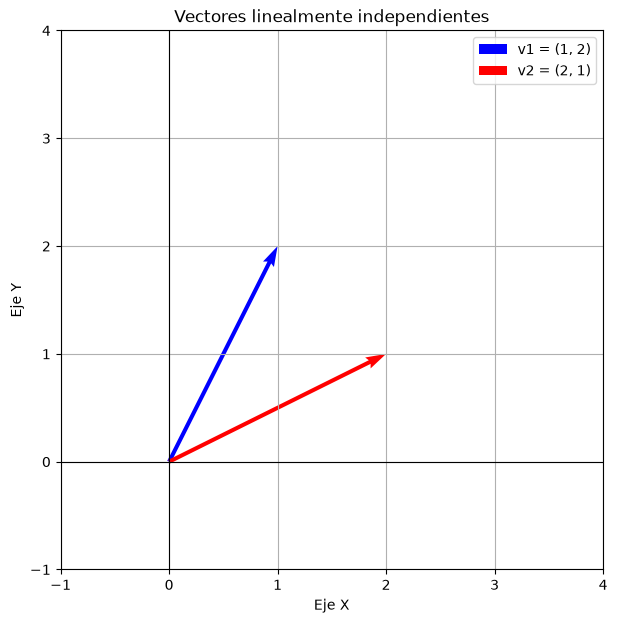

In [42]:

# Definir los vectores
v1 = np.array([1, 2])
v2 = np.array([2, 1])

# Crear la gráfica
plt.figure(figsize=(7, 7))

# Vector v1 en azul
plt.quiver(0, 0, v1[0], v1[1],
           angles='xy', scale_units='xy', scale=1,
           color='blue',
           label='v1 = (1, 2)')

# Vector v2 en rojo
plt.quiver(0, 0, v2[0], v2[1],
           angles='xy', scale_units='xy', scale=1,
           color='red',
           label='v2 = (2, 1)')

# Ejes X e Y
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

# Límites de la gráfica
plt.xlim(-1, 4)
plt.ylim(-1, 4)

# Cuadrícula y etiquetas
plt.grid()
plt.xlabel("Eje X")
plt.ylabel("Eje Y")
plt.title("Vectores linealmente independientes")
plt.legend()

plt.show()

### Explicación

Para determinar si los vectores \(v_1\) y \(v_2\) son linealmente independientes, primero se colocan como columnas de una matriz utilizando `np.column_stack()`.

Posteriormente, se utiliza `np.linalg.matrix_rank()`, una función del módulo de álgebra lineal de NumPy, que permite calcular el rango de una matriz. El rango indica el número máximo de filas o columnas linealmente independientes; es decir, cuántas direcciones independientes aportan los vectores.

En este caso, la matriz contiene 2 vectores y se obtiene un rango igual a 2. Como el rango coincide con el número de vectores, se concluye que \(v_1\) y \(v_2\) son linealmente independientes.

Esto significa que ninguno de los vectores puede expresarse como múltiplo o combinación lineal del otro. Si el rango hubiera sido menor que el número de vectores, se concluiría que son linealmente dependientes.


### 4. Explica qué significa que generen el espacio.

Se utiliza el término espacio porque los vectores representan puntos o direcciones dentro de un conjunto definido por sus dimensiones. El número de componentes de cada vector determina el espacio al que pertenece; por ejemplo, un vector con dos componentes pertenece a R^2, que puede representarse como un plano.

En nuestro ejercicio, \(v_1=(1,2)\) y \(v_2=(2,1)\) pertenecen a R^2. Decir que generan el espacio significa que, mediante diferentes combinaciones lineales de estos dos vectores, podemos obtener cualquier vector o punto de R^2.

Como ambos vectores son linealmente independientes y el rango es 2, aportan dos direcciones independientes y, en conjunto, permiten recorrer todo el plano. Por esta razón:

$$ \operatorname{span}\{v_1,v_2\}=\mathbb{R}^2 $$

El término span representa precisamente el conjunto de todas las combinaciones lineales que pueden construirse con esos vectores.

El espacio indica “dónde viven” los vectores, mientras que generar el espacio significa que sus combinaciones permiten alcanzar cualquier punto de ese espacio.

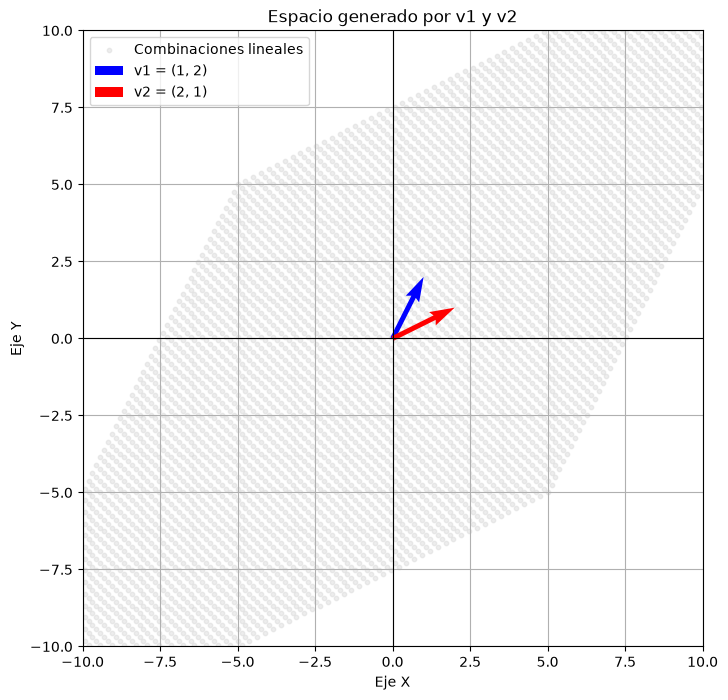

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Definir los vectores
v1 = np.array([1, 2])
v2 = np.array([2, 1])

# Valores para alpha y beta
valores = np.linspace(-5, 5, 80)

# Generar combinaciones lineales
puntos = []

for alpha in valores:
    for beta in valores:
        punto = alpha * v1 + beta * v2
        puntos.append(punto)

puntos = np.array(puntos)

# Crear gráfica
plt.figure(figsize=(8, 8))

# Espacio generado por las combinaciones lineales
plt.scatter(puntos[:, 0], puntos[:, 1],
            color='lightgray',
            alpha=0.4,
            s=10,
            label='Combinaciones lineales')

# Vector v1
plt.quiver(0, 0, v1[0], v1[1],
           angles='xy',
           scale_units='xy',
           scale=1,
           color='blue',
           width=0.008,
           label='v1 = (1, 2)')

# Vector v2
plt.quiver(0, 0, v2[0], v2[1],
           angles='xy',
           scale_units='xy',
           scale=1,
           color='red',
           width=0.008,
           label='v2 = (2, 1)')

# Ejes
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

# Límites
plt.xlim(-10, 10)
plt.ylim(-10, 10)

# Configuración
plt.grid()
plt.xlabel("Eje X")
plt.ylabel("Eje Y")
plt.title("Espacio generado por v1 y v2")
plt.legend()

plt.show()

La gráfica muestra una aproximación visual del espacio generado por v1 y v2. Al permitir que alpha y beta tomen valores reales, sus combinaciones lineales pueden alcanzar cualquier punto de R^2. En la gráfica solo se representa un intervalo finito de valores reales, pero matemáticamente los escalares pueden tomar cualquier valor en, por lo que los vectores generan todo el plano.

## Ejercicio 5 — ¿Lineal o afín?

Define:

$$
A=\begin{bmatrix}2&1\\-1&3\end{bmatrix},
\qquad
b=(4,-2)
$$

y las funciones:

$$
T_1(x)=Ax,\qquad T_2(x)=Ax+b.
$$

### Tareas
1. Implementa ambas.
2. Con vectores `u`, `v` y un escalar $\alpha$, comprueba:
$$
T(u+v)=T(u)+T(v)
$$
y
$$
T(\alpha u)=\alpha T(u).
$$
3. Identifica cuál es lineal y cuál es afín.
4. Relaciona el resultado con \(Wx+b\) en una capa densa.

**Indicio:** usa `np.allclose`.

In [44]:
A = np.array([[2, 1], [-1, 3]])
b = np.array([4, -2])

def T1(x):
    return A @ x

def T2(x):
    return A @ x + b

# Vectores y escalar para comprobación
u = np.array([1, 0])
v = np.array([0, 1])
alfa = 2

# Comprobaciones para T1 (Lineal)
print("--- Comprobaciones para T1 (Lineal) ---")
print("T1(u+v) == T1(u)+T1(v):", np.allclose(T1(u + v), T1(u) + T1(v)))
print("T1(alpha*u) == alpha*T1(u):", np.allclose(T1(alfa * u), alfa * T1(u)))

# Comprobaciones para T2 (Afín)
print("\n--- Comprobaciones para T2 (Afín) ---")
print("T2(u+v) == T2(u)+T2(v):", np.allclose(T2(u + v), T2(u) + T2(v)))
print("T2(alpha*u) == alpha*T2(u):", np.allclose(T2(alfa * u), alfa * T2(u)))

--- Comprobaciones para T1 (Lineal) ---
T1(u+v) == T1(u)+T1(v): True
T1(alpha*u) == alpha*T1(u): True

--- Comprobaciones para T2 (Afín) ---
T2(u+v) == T2(u)+T2(v): False
T2(alpha*u) == alpha*T2(u): False


### Explicación del Ejercicio 5

**Funciones Lineales vs. Afines:**

- Una **transformación lineal** $T$ satisface dos propiedades clave:
    1.  Aditividad: $T(u+v) = T(u) + T(v)$
    2.  Homogeneidad: $T(\text{escalar} \times u) = \text{escalar} \times T(u)$
    La función $T_1(x) = Ax$ cumple ambas propiedades, por lo tanto, es una transformación lineal.

- Una **transformación afín** es una transformación lineal seguida de una traslación. Es decir, $T_2(x) = Ax + b$. No cumple la propiedad de aditividad ni de homogeneidad si $b \ne 0$. Por ejemplo, $T_2(u+v) = A(u+v)+b = Au+Av+b$, mientras que $T_2(u)+T_2(v) = (Au+b) + (Av+b) = Au+Av+2b$. Solo son iguales si $b=0$.

**Relación con Deep Learning ($Wx+b$):**

La expresión $Wx+b$ es fundamental en las redes neuronales, donde $W$ es la matriz de pesos, $x$ es el vector de entrada y $b$ es el vector de sesgo (bias). Esta es precisamente la forma de una **transformación afín**.

En una capa densa (o *fully connected*), la operación central es una transformación afín: la entrada se multiplica por una matriz de pesos y luego se le suma un vector de sesgo. Esta transformación afín es crucial porque, a diferencia de una transformación puramente lineal, permite a la red modelar relaciones más complejas, especialmente tras cada activación no lineal. Sin el término de bias ($b$), la red solo podría modelar funciones que pasan por el origen.

## Ejercicio 6 — Hiperplano y clasificación

Una neurona utiliza:

$$
z=w^Tx+b
$$

con:

$$
w=(2,1),\qquad b=-4.
$$

### Tareas
1. Encuentra la frontera $w^Tx+b=0$.
2. Genera al menos 12 puntos aleatorios.
3. Calcula `z` y clasifica con $z\ge 0$ como clase 1 y $z<0$ como clase 0.
4. Grafica las dos clases y la frontera.
5. Dibuja `w` desde un punto de la frontera.
6. Explica por qué `w` es perpendicular a la frontera.

**Indicio:** despeja $x_2$ y usa `plt.quiver()`.

## Ejercicio 7 — Autovalores y autovectores

Considera:

$$
A=\begin{bmatrix}
4&1\\
2&3
\end{bmatrix}.
$$

### Tareas
1. Calcula autovalores y autovectores.
2. Verifica $Av=\lambda v$.
3. Normaliza cada autovector.
4. Grafica cada autovector y su versión transformada.
5. Explica qué sucede con la dirección.
6. Interpreta el autovalor como factor de escalamiento.

**Indicio:** `np.linalg.eig()` devuelve los autovectores por columnas.

### 1. Calcula autovalores y autovectores.

In [45]:

# Definir la matriz A
A = np.array([
    [4, 1],
    [2, 3]
])

# Calcular autovalores y autovectores
autovalores, autovectores = np.linalg.eig(A)

print("Autovalores:")
print(autovalores)

print("\nAutovectores:")
print(autovectores)

Autovalores:
[5. 2.]

Autovectores:
[[ 0.7071 -0.4472]
 [ 0.7071  0.8944]]


Los autovectores representan direcciones especiales que se mantienen cuando se aplica la transformación definida por una matriz. Aunque su magnitud puede cambiar, conservan su dirección. Los autovalores indican el factor por el cual se escala cada autovector. En este ejercicio, np.linalg.eig(A) obtiene los autovalores 5 y 2 junto con sus respectivos autovectores. NumPy devuelve los autovectores organizados por columnas, por lo que cada autovalor está asociado con la columna correspondiente de la matriz de autovectores.

### 2. Verifica  Av=λv

La condición que debe cumplirse es:

$$ \boxed{Av=\lambda v} $$

Es decir, si tomamos un autovector \(v\) y lo multiplicamos por la matriz \(A\), debemos obtener lo mismo que si multiplicamos ese vector por su autovalor $$\lambda$$.

In [46]:
# Verificar Av = λv para cada autovalor y autovector

for i in range(len(autovalores)):

    # Seleccionar autovalor
    lambda_i = autovalores[i]

    # Seleccionar su autovector correspondiente
    v = autovectores[:, i]

    # Calcular ambos lados de la ecuación
    Av = A @ v
    lambda_v = lambda_i * v

    print(f"\nAutovalor λ = {lambda_i}")
    print("Autovector v =", v)

    print("Av =", Av)
    print("λv =", lambda_v)

    # Verificar si son aproximadamente iguales
    print("¿Av = λv?", np.allclose(Av, lambda_v))


Autovalor λ = 5.0
Autovector v = [0.7071 0.7071]
Av = [3.5355 3.5355]
λv = [3.5355 3.5355]
¿Av = λv? True

Autovalor λ = 2.0
Autovector v = [-0.4472  0.8944]
Av = [-0.8944  1.7889]
λv = [-0.8944  1.7889]
¿Av = λv? True


Para verificar que los valores obtenidos corresponden realmente a autovalores y autovectores, se comprueba la relación \(Av=\lambda v\). Se multiplica cada autovector por la matriz \(A\) y se compara el resultado con el mismo autovector multiplicado por su autovalor. En ambos casos los resultados coinciden, por lo que se verifica la propiedad fundamental de los autovalores y autovectores. np.allclose() permite comprobar esta igualdad considerando pequeñas diferencias de precisión numérica

### 3. Normaliza cada autovector

Normalizar un vector significa cambiar su longitud para que sea igual a 1, pero sin cambiar su dirección.

Por ejemplo, tenemos:

$$ v=(1,1) $$

Su longitud o norma es:

$$ ||v||=\sqrt{1^2+1^2}=\sqrt{2}\approx1.414 $$

Para normalizarlo, dividimos cada componente entre su norma:

$$ v_{norm}=\frac{v}{||v||} $$

Entonces:

$$ v_{norm} = \frac{(1,1)}{1.414} = (0.7071,0.7071) $$


In [47]:
# Normalizar cada autovector

autovectores_normalizados = []

for i in range(autovectores.shape[1]):

    # Obtener el autovector de la columna i
    v = autovectores[:, i]

    # Calcular su norma (longitud)
    norma = np.linalg.norm(v)

    # Normalizar el vector
    v_normalizado = v / norma

    autovectores_normalizados.append(v_normalizado)

    print(f"\nAutovector {i+1}:")
    print("Vector original:", v)
    print("Norma:", norma)
    print("Vector normalizado:", v_normalizado)
    print("Norma después de normalizar:",
          np.linalg.norm(v_normalizado))


Autovector 1:
Vector original: [0.7071 0.7071]
Norma: 0.9999999999999999
Vector normalizado: [0.7071 0.7071]
Norma después de normalizar: 1.0

Autovector 2:
Vector original: [-0.4472  0.8944]
Norma: 0.9999999999999999
Vector normalizado: [-0.4472  0.8944]
Norma después de normalizar: 1.0


Normalizar un autovector consiste en dividirlo por su norma para obtener un vector de longitud 1, conservando su dirección. Esto facilita la comparación e interpretación de los autovectores independientemente de su magnitud. En este caso, np.linalg.eig() ya devuelve los autovectores normalizados, por lo que sus normas son aproximadamente iguales a 1. La función np.linalg.norm() permite calcular y verificar la longitud de cada vector.

### 4. Grafica cada autovector y su versión transformada.

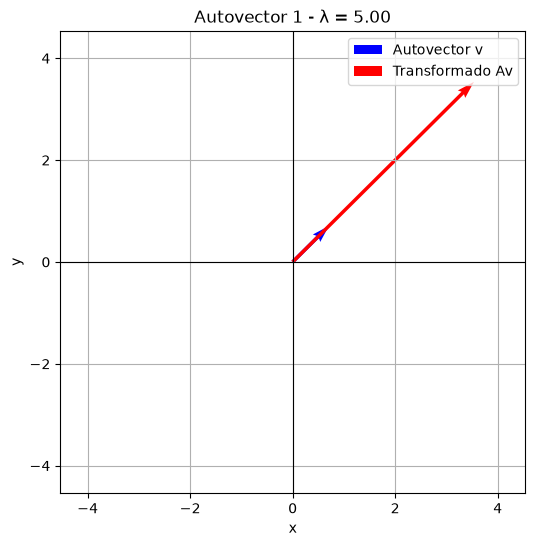

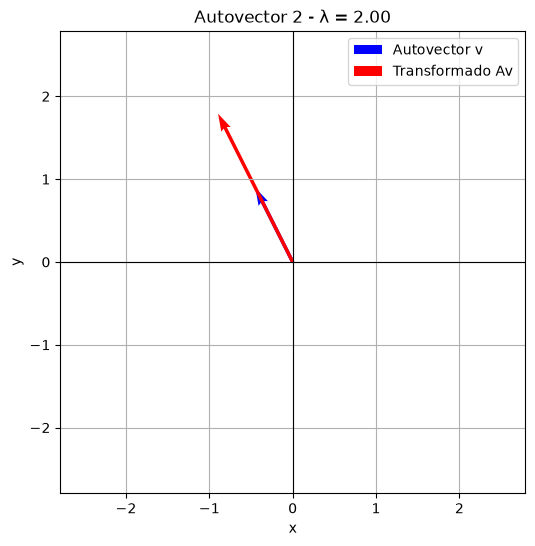

In [48]:
# Graficar cada autovector y su versión transformada
for i in range(len(autovalores)):

    # Tomamos el autovector i
    v = autovectores[:, i]

    # Aplicamos la transformación A
    Av = A @ v

    # Crear gráfica
    plt.figure(figsize=(6, 6))

    # Autovector original
    plt.quiver(
        0, 0, v[0], v[1],
        angles='xy',
        scale_units='xy',
        scale=1,
        color='blue',
        label='Autovector v'
    )

    # Autovector transformado
    plt.quiver(
        0, 0, Av[0], Av[1],
        angles='xy',
        scale_units='xy',
        scale=1,
        color='red',
        label='Transformado Av'
    )

    # Ejes
    plt.axhline(0, color='black', linewidth=0.8)
    plt.axvline(0, color='black', linewidth=0.8)

    # Límites
    limite = np.max(np.abs(Av)) + 1
    plt.xlim(-limite, limite)
    plt.ylim(-limite, limite)

    # Cuadrícula y etiquetas
    plt.grid()
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(
        f"Autovector {i+1} - λ = {autovalores[i]:.2f}"
    )
    plt.legend()

    plt.show()

### 5. Explica qué sucede con la dirección.

Explicación: Al aplicar la transformación A, los autovectores conservan su dirección. Lo que cambia es su magnitud, determinada por el autovalor asociado. En este caso, como los autovalores son positivos (5 y 2), los vectores mantienen también su sentido y se escalan por factores de 5 y 2, respectivamente.

Un detalle importante: si el autovalor fuera negativo, seguiría sobre la misma línea, pero cambiaría de sentido.

### 6. Interpreta el autovalor como factor de escalamiento.

In [49]:
# Interpretar el autovalor como factor de escalamiento

for i in range(len(autovalores)):

    # Autovalor y autovector
    lambda_i = autovalores[i]
    v = autovectores[:, i]

    # Aplicar la transformación
    Av = A @ v

    # Calcular las magnitudes
    norma_v = np.linalg.norm(v)
    norma_Av = np.linalg.norm(Av)

    # Calcular cuánto se escaló
    factor_escalamiento = norma_Av / norma_v

    print(f"\nAutovector {i+1}")
    print("Autovalor:", lambda_i)
    print("Magnitud original:", norma_v)
    print("Magnitud transformada:", norma_Av)
    print("Factor de escalamiento:", factor_escalamiento)


Autovector 1
Autovalor: 5.0
Magnitud original: 0.9999999999999999
Magnitud transformada: 5.0
Factor de escalamiento: 5.000000000000001

Autovector 2
Autovalor: 2.0
Magnitud original: 0.9999999999999999
Magnitud transformada: 2.0
Factor de escalamiento: 2.0000000000000004


En nuestro caso, como ambos autovalores son positivos:

$$ \boxed{5 \rightarrow \text{escala 5 veces}} $$ $$ \boxed{2 \rightarrow \text{escala 2 veces}} $$

Mediante np.linalg.norm() se calcula la magnitud del autovector antes y después de aplicar la transformación. Al dividir la magnitud transformada entre la magnitud original, se obtiene el factor de escalamiento. Los resultados muestran factores de 5 y 2, que coinciden con los autovalores obtenidos. Esto confirma que el autovalor determina cuánto se escala la magnitud de su autovector asociado.

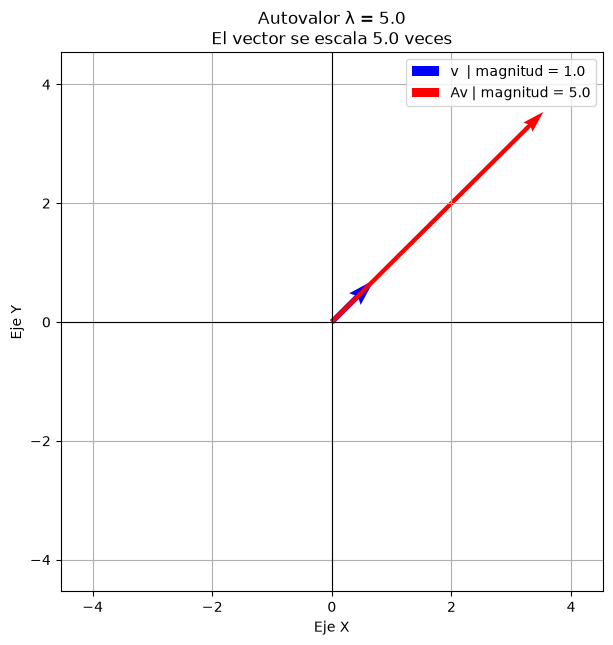

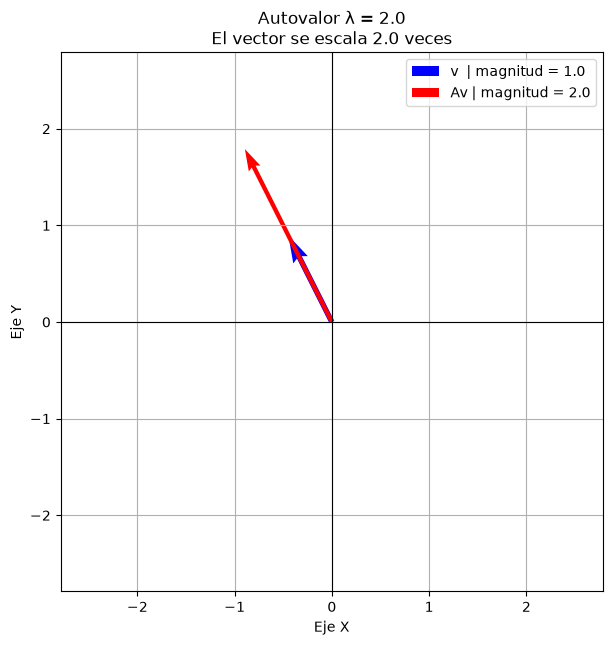

In [50]:

for i in range(len(autovalores)):

    # Autovalor y autovector
    lambda_i = autovalores[i]
    v = autovectores[:, i]

    # Vector transformado
    Av = A @ v

    # Magnitudes
    norma_v = np.linalg.norm(v)
    norma_Av = np.linalg.norm(Av)

    # Crear gráfica
    plt.figure(figsize=(7, 7))

    # Autovector original
    plt.quiver(
        0, 0, v[0], v[1],
        angles='xy',
        scale_units='xy',
        scale=1,
        color='blue',
        width=0.01,
        label=f'v  | magnitud = {norma_v:.1f}'
    )

    # Vector transformado
    plt.quiver(
        0, 0, Av[0], Av[1],
        angles='xy',
        scale_units='xy',
        scale=1,
        color='red',
        width=0.008,
        label=f'Av | magnitud = {norma_Av:.1f}'
    )

    # Ejes
    plt.axhline(0, color='black', linewidth=0.8)
    plt.axvline(0, color='black', linewidth=0.8)

    # Límites
    limite = np.max(np.abs(Av)) + 1
    plt.xlim(-limite, limite)
    plt.ylim(-limite, limite)

    plt.grid()
    plt.xlabel("Eje X")
    plt.ylabel("Eje Y")

    plt.title(
        f"Autovalor λ = {lambda_i:.1f}\n"
        f"El vector se escala {abs(lambda_i):.1f} veces"
    )

    plt.legend()
    plt.show()

Gráficamente se observa que el autovalor actúa como factor de escalamiento. El autovector original tiene magnitud 1 y, después de aplicar la transformación, su magnitud pasa a 5 o 2 según su autovalor asociado. La dirección se mantiene, pero la longitud del vector cambia en función del autovalor.

## Ejercicio 8 — Experimento integrador

Utiliza:

$$
A=\begin{bmatrix}3&1\\1&3\end{bmatrix}.
$$

### Tareas
1. Genera una nube de 100 puntos.
2. Aplica $Y=XA^T$.
3. Grafica antes y después.
4. Calcula autovalores y autovectores.
5. Superpone los autovectores normalizados.
6. Calcula $\|Av\|\|v\|$ para cada autovector.
7. Explica qué direcciones se amplifican más y por qué.

**Indicio:** compara el cociente anterior con $|\lambda|$.

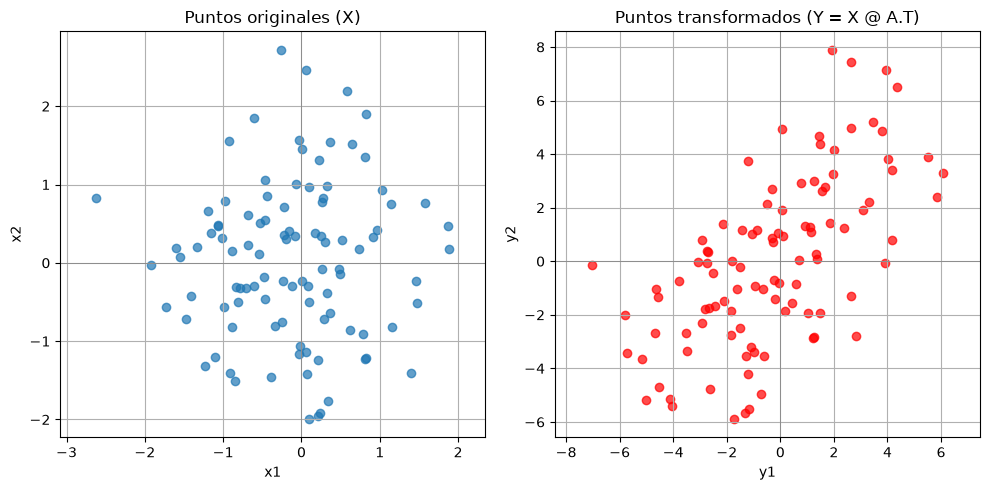

In [51]:
A = np.array([[3, 1], [1, 3]])

# 1. Generar una nube de 100 puntos
np.random.seed(42) # Para reproducibilidad
X = np.random.randn(100, 2) # 100 puntos en 2D, distribuidos normalmente alrededor del origen

# 2. Aplicar la transformación Y = X @ A.T
Y = X @ A.T

# 3. Graficar antes y después
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], alpha=0.7)
plt.title('Puntos originales (X)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.axis('equal')

plt.subplot(1, 2, 2)
plt.scatter(Y[:, 0], Y[:, 1], alpha=0.7, color='red')
plt.title('Puntos transformados (Y = X @ A.T)')
plt.xlabel('y1')
plt.ylabel('y2')
plt.grid(True)
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.axis('equal')

plt.tight_layout()
plt.show()

Autovalores: [4. 2.]
Autovectores (columnas):
 [[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]


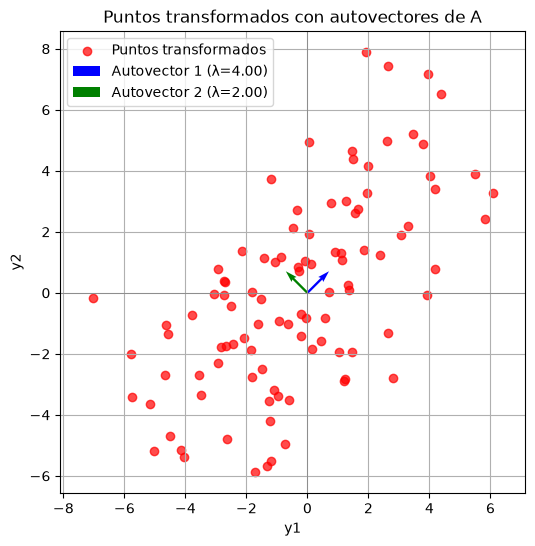

In [52]:
# 4. Calcular autovalores y autovectores
autovalores, autovectores = np.linalg.eig(A)

print("Autovalores:", autovalores)
print("Autovectores (columnas):\n", autovectores)

# 5. Superponer los autovectores normalizados en la gráfica transformada
plt.figure(figsize=(6, 6))
plt.scatter(Y[:, 0], Y[:, 1], alpha=0.7, color='red', label='Puntos transformados')
plt.title('Puntos transformados con autovectores de A')
plt.xlabel('y1')
plt.ylabel('y2')
plt.grid(True)
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.axis('equal')

# Normalizar autovectores para graficarlos con una longitud unitaria inicial
v1 = autovectores[:, 0]
v2 = autovectores[:, 1]

# Graficar los autovectores normalizados desde el origen
plt.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.005, label=f'Autovector 1 (λ={autovalores[0]:.2f})')
plt.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='green', width=0.005, label=f'Autovector 2 (λ={autovalores[1]:.2f})')

plt.legend()
plt.show()

In [53]:
# 6. Calcular ||Av|| / ||v|| para cada autovector
for i in range(len(autovalores)):
    v = autovectores[:, i]
    lambda_val = autovalores[i]

    Av = A @ v
    norm_v = np.linalg.norm(v)
    norm_Av = np.linalg.norm(Av)

    print(f"\nPara autovector {i+1} (λ = {lambda_val:.4f}):")
    print(f"  ||v|| = {norm_v:.4f}")
    print(f"  ||Av|| = {norm_Av:.4f}")
    print(f"  ||Av|| / ||v|| = {norm_Av / norm_v:.4f}")
    print(f"  Comparación con |λ|: |λ| = {np.abs(lambda_val):.4f}")


Para autovector 1 (λ = 4.0000):
  ||v|| = 1.0000
  ||Av|| = 4.0000
  ||Av|| / ||v|| = 4.0000
  Comparación con |λ|: |λ| = 4.0000

Para autovector 2 (λ = 2.0000):
  ||v|| = 1.0000
  ||Av|| = 2.0000
  ||Av|| / ||v|| = 2.0000
  Comparación con |λ|: |λ| = 2.0000


### Explicación del Ejercicio 8

**Transformación y Autovectores/Autovalores:**

Al aplicar la transformación $Y = X A^T$ (o $Y = X A$, dependiendo de la convención de fila/columna, aquí estamos usando $A^T$ para mantener la forma de los puntos), la nube de puntos original se estira y rota. Los **autovectores** de la matriz $A$ son direcciones especiales en el espacio que, al ser transformadas por $A$, solo cambian de escala, no de dirección (o su dirección se invierte, pero siguen en la misma línea). Los **autovalores** $(\lambda)$ son los factores por los cuales estas direcciones se escalan.

**¿Qué direcciones se amplifican más y por qué?**

Observando la relación $\frac{\|Av\|}{\|v\|}$ y comparándola con el valor absoluto de cada autovalor ($|\lambda|$), vemos que son iguales. Esto demuestra que el autovalor nos indica el factor de escalamiento que experimenta un autovector cuando la transformación $A$ se aplica a él.

En nuestro caso, ambos autovalores son positivos (4 y 2), lo que significa que los puntos a lo largo de las direcciones definidas por los autovectores se estiran, no se invierten ni se encogen (excepto si el autovalor fuera entre 0 y 1). El autovector asociado al autovalor más grande ($\lambda=4$) es la dirección a lo largo de la cual la nube de puntos se estira más significativamente, mientras que el autovector asociado al autovalor más pequeño ($\lambda=2$) es la dirección de menor estiramiento. Visualmente, en la gráfica transformada, la nube de puntos se alinea y se alarga a lo largo de la dirección del autovector con el mayor autovalor.

En Deep Learning, los autovalores y autovectores pueden ser relevantes para entender cómo ciertas transformaciones (como las capas lineales) afectan la distribución de los datos, identificando las direcciones de máxima varianza o de mayor 'estiramiento' de la información. Esto es clave en técnicas como PCA (Análisis de Componentes Principales) y para entender la geometría del espacio de características que una red neuronal está aprendiendo.

## Ejercicio 9 — Mini-reto: Crea una capa neuronal desde cero

Construye una capa densa usando solo NumPy:

$$
z=Wx+b
$$

Usa $x\in\mathbb{R}^4$, $W\in\mathbb{R}^{3,4}$ y $b\in\mathbb{R}^3$.

### Tareas
1. Crea los datos.
2. Verifica `shape`.
3. Implementa la transformación.
4. Explica por qué dos transformaciones afines consecutivas pueden componerse en una sola.

**Indicio:** `z = W @ x + b` y `np.maximum(0, z)`.

## Reflexión final

Responde con tus propias palabras:

1. ¿Cuál es la diferencia entre vector, matriz y tensor?
2. ¿Qué significa transformar una representación?
3. ¿Por qué \(Wx+b\) aparece en una neurona?
4. ¿Qué información ofrecen autovalores y autovectores?
5. ¿Qué relación encuentras entre estos conceptos y una futura red neuronal profunda?

## Criterios de calidad

Una buena solución debe incluir:

- código correcto y legible;
- verificación de `shape`;
- explicación matemática;
- comprobaciones numéricas;
- visualizaciones cuando sean pertinentes;
- interpretación vinculada con Deep Learning.

**No se evaluará solamente si el código "corre".**